# Documentation corpus findings

This notebook summarizes `documentation_files.jsonl` produced by `pull_documentation_files.py`. Each JSONL row represents one documentation file and includes its repository, branch, path, SHA, and text content.

It answers:

- How many repositories and documentation files were collected?
- Which filenames occur most often (for example, `README.md`, `SKILL.md`, and `AGENTS.md`)?
- Which repositories contain the most documentation files?
- Which extensions and directories are most common?
- How large is the collected documentation corpus, and are there duplicate file contents?

In [1]:
from __future__ import annotations

import hashlib
import json
from pathlib import Path, PurePosixPath

import matplotlib.pyplot as plt
import pandas as pd

INPUT_PATH = Path("documentation_files.jsonl")
TOP_N = 20

pd.set_option("display.max_colwidth", 100)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Load JSONL and retain malformed rows for a data-quality check.
if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Could not find {INPUT_PATH.resolve()}")

records, invalid_rows = [], []
with INPUT_PATH.open(encoding="utf-8") as jsonl_file:
    for line_number, line in enumerate(jsonl_file, start=1):
        if not line.strip():
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as exc:
            invalid_rows.append({"line": line_number, "error": str(exc)})

df = pd.DataFrame(records)
required_columns = {"repository", "repository_url", "branch", "path", "sha", "content"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"JSONL is missing expected columns: {sorted(missing_columns)}")

df["path"] = df["path"].astype(str)
df["file_name"] = df["path"].map(lambda path: PurePosixPath(path).name)
df["file_name_normalized"] = df["file_name"].str.casefold()
df["extension"] = df["path"].map(lambda path: PurePosixPath(path).suffix.lower() or "[no extension]")
df["directory"] = df["path"].map(lambda path: str(PurePosixPath(path).parent))
df["is_root_file"] = df["directory"].eq(".")
df["content"] = df["content"].fillna("").astype(str)
df["characters"] = df["content"].str.len()
df["content_hash"] = df["content"].map(lambda text: hashlib.sha256(text.encode("utf-8")).hexdigest())

print(f"Loaded {len(df):,} documentation records from {INPUT_PATH}.")
print(f"Malformed non-empty JSONL rows: {len(invalid_rows):,}")
if invalid_rows:
    display(pd.DataFrame(invalid_rows).head())

Loaded 96,231 documentation records from documentation_files.jsonl.
Malformed non-empty JSONL rows: 0


## Corpus overview and data quality

In [3]:
summary = pd.Series({
    "Documentation files": len(df),
    "Repositories": df["repository"].nunique(),
    "Branches": df["branch"].nunique(),
    "Root-level files": int(df["is_root_file"].sum()),
    "Nested files": int((~df["is_root_file"]).sum()),
    "Total characters": int(df["characters"].sum()),
    "Median characters per file": int(df["characters"].median()),
    "Empty files": int(df["content"].eq("").sum()),
    "Duplicate-content records": int(df.duplicated("content_hash", keep=False).sum()),
})
display(summary.to_frame("value"))

# A duplicate source record indicates that a prior --resume run may have appended it.
duplicate_sources = df.duplicated(["repository", "branch", "path", "sha"], keep=False)
print(f"Duplicate source records: {duplicate_sources.sum():,}")
if duplicate_sources.any():
    display(df.loc[duplicate_sources, ["repository", "branch", "path", "sha"]].sort_values(["repository", "path"]).head(20))

,value
Documentation files,96231
Repositories,163
Branches,11
Root-level files,1114
Nested files,95117
Total characters,873735740
Median characters per file,4048
Empty files,151
Duplicate-content records,34294


Duplicate source records: 0


## Most frequent filenames

Filenames are grouped case-insensitively, so `README.md` and `readme.md` count together. This is useful for spotting common repository conventions and guidance files.

,filename,files,repositories
19614,README.md,8530,162
21983,SKILL.md,5601,113
17624,overview.mdx,2116,20
4403,AGENTS.md,1007,106
4932,api-reference.md,826,11
13584,index.mdx,620,27
7211,CHANGELOG.md,505,76
20302,requirements.txt,468,66
13583,index.md,410,39
7645,CLAUDE.md,405,83


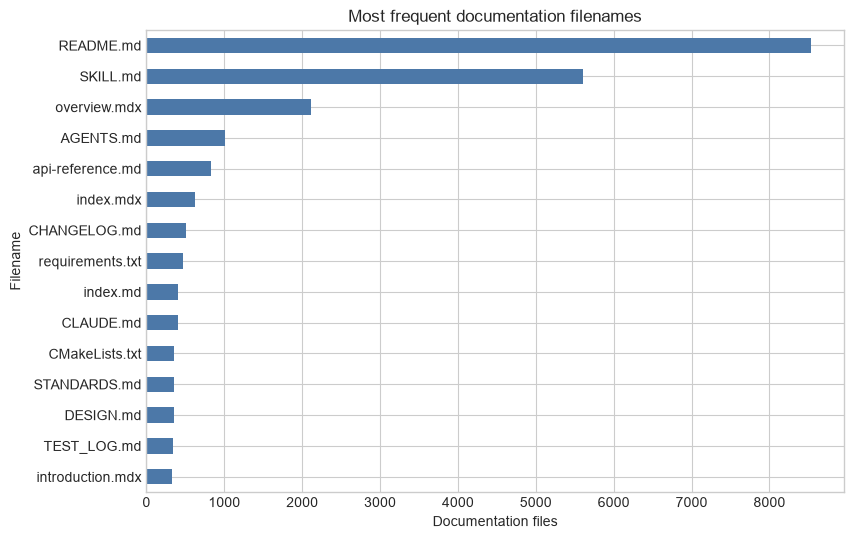

In [4]:
filename_counts = (
    df.groupby("file_name_normalized", as_index=False)
      .agg(files=("path", "size"), example_spelling=("file_name", "first"), repositories=("repository", "nunique"))
      .sort_values(["files", "repositories"], ascending=False)
)
display(filename_counts.head(TOP_N).rename(columns={"example_spelling": "filename"})[["filename", "files", "repositories"]])

guidance_names = ["agents.md", "skill.md", "claude.md", "contributing.md", "security.md", "readme.md"]
guidance_counts = filename_counts[filename_counts["file_name_normalized"].isin(guidance_names)]

chart_data = filename_counts.head(15).sort_values("files")
ax = chart_data.plot.barh(x="example_spelling", y="files", legend=False, figsize=(9, 6), color="#4C78A8")
ax.set(xlabel="Documentation files", ylabel="Filename", title="Most frequent documentation filenames")
plt.show()

## Repositories with the most documentation

The table combines document count, total corpus size, and the number of distinct directories. The last measure helps distinguish repositories with a few large docs from documentation distributed across the codebase.

,repository,repository_url,documentation_files,total_characters,median_characters,unique_directories,root_files
76,crewAIInc/crewAI,https://github.com/crewAIInc/crewAI,27983,211345399,4490,4056,3
114,microsoft/ai-agents-for-beginners,https://github.com/microsoft/ai-agents-for-beginners,3514,39475510,9436,2339,8
159,xbtlin/ai-berkshire,https://github.com/xbtlin/ai-berkshire,2676,26850091,5038,439,9
120,mukul975/Anthropic-Cybersecurity-Skills,https://github.com/mukul975/Anthropic-Cybersecurity-Skills,2587,12229069,2543,1932,9
54,affaan-m/ECC,https://github.com/affaan-m/ECC,2557,13642771,3483,1114,16
74,code-yeongyu/oh-my-openagent,https://github.com/code-yeongyu/oh-my-openagent,2417,29227937,2321,677,14
11,CopilotKit/CopilotKit,https://github.com/CopilotKit/CopilotKit,2325,8615940,1866,805,7
121,nexu-io/open-design,https://github.com/nexu-io/open-design,2250,19358039,4220,1193,12
60,apache/airflow,https://github.com/apache/airflow,2246,13004692,2311,532,15
130,openclaw/openclaw,https://github.com/openclaw/openclaw,2138,27270857,5843,435,8


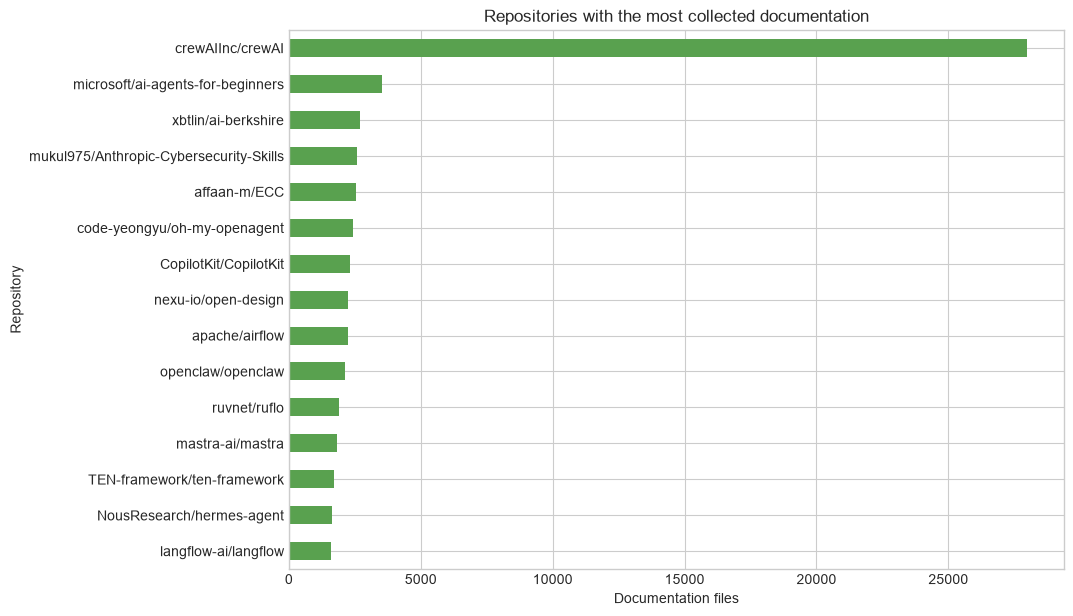

In [5]:
repo_summary = (
    df.groupby(["repository", "repository_url"], as_index=False)
      .agg(
          documentation_files=("path", "size"),
          total_characters=("characters", "sum"),
          median_characters=("characters", "median"),
          unique_directories=("directory", "nunique"),
          root_files=("is_root_file", "sum"),
      )
      .sort_values(["documentation_files", "total_characters"], ascending=False)
)
repo_summary["total_characters"] = repo_summary["total_characters"].astype(int)
repo_summary["median_characters"] = repo_summary["median_characters"].astype(int)
display(repo_summary.head(TOP_N))

chart_data = repo_summary.head(15).sort_values("documentation_files")
ax = chart_data.plot.barh(x="repository", y="documentation_files", legend=False, figsize=(10, 7), color="#59A14F")
ax.set(xlabel="Documentation files", ylabel="Repository", title="Repositories with the most collected documentation")
plt.show()

## File types, locations, and content size

,extension,files
0,.md,50150
1,.mdx,39084
2,.txt,5009
3,.rst,1969
4,.markdown,19


,location,files
0,docs,44037
1,skills,5165
2,packages,4803
3,translations,3471
4,reports,2593
5,.agents,2016
6,showcase,1951
7,plugins,1843
8,.omo,1780
9,providers,1447


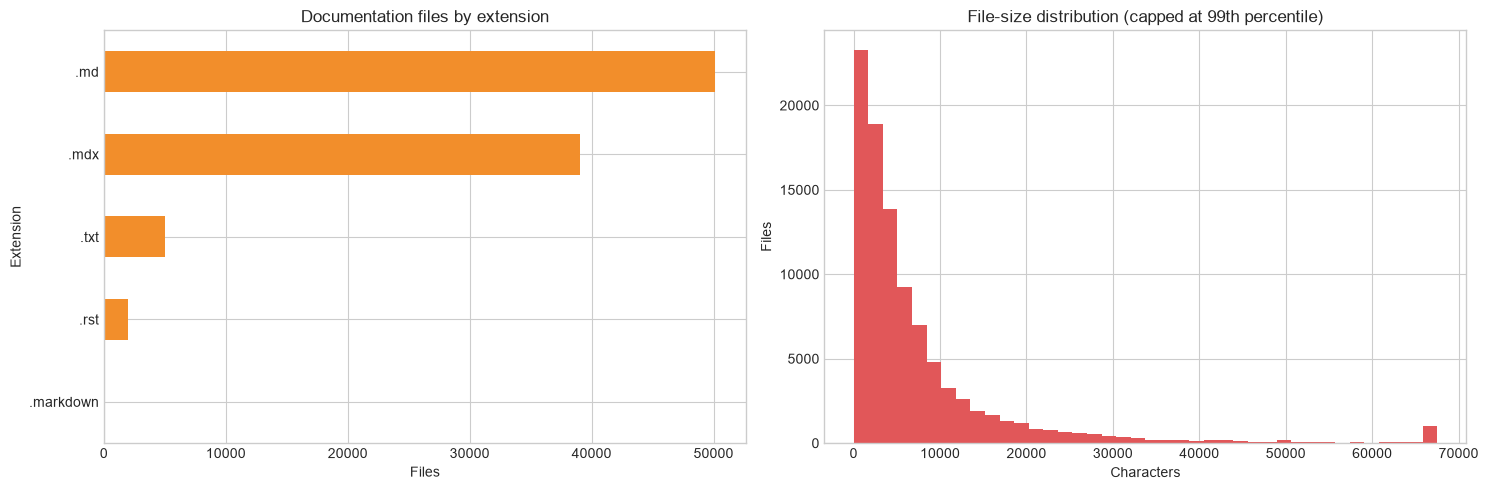

In [6]:
extension_counts = df["extension"].value_counts().rename_axis("extension").reset_index(name="files")
display(extension_counts)

# The first directory component is a compact view of where documentation tends to live.
df["top_level_directory"] = df["path"].map(lambda path: PurePosixPath(path).parts[0] if len(PurePosixPath(path).parts) > 1 else "[root]")
top_level_counts = df["top_level_directory"].value_counts().head(TOP_N).rename_axis("location").reset_index(name="files")
display(top_level_counts)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
extension_counts.sort_values("files").plot.barh(x="extension", y="files", legend=False, ax=axes[0], color="#F28E2B")
axes[0].set(title="Documentation files by extension", xlabel="Files", ylabel="Extension")
df["characters"].clip(upper=df["characters"].quantile(0.99)).plot.hist(bins=40, ax=axes[1], color="#E15759")
axes[1].set(title="File-size distribution (capped at 99th percentile)", xlabel="Characters", ylabel="Files")
plt.tight_layout()
plt.show()

## Related outputs and follow-up analysis

The collection is complete: 96,231 records from 163 of the 175 input repositories. See `Documentation_Collection_Summary.md` for the written findings and the 12 repositories without records.

Topic modelling is done in `topic_modelling/`: `bertopic_documentation_topics.py` assigns each record a topic and doc type in `documentation_topics.csv`, summarized in `topic_modelling/Topic_Modelling_Summary.md`.

Remaining questions:

- Compare `AGENTS.md`, `SKILL.md`, and `CLAUDE.md` content to identify recurring agent instructions.
- Deduplicate identical files before using the corpus for retrieval or model training: 34,294 records share content with another record, 79% of them from `crewAIInc/crewAI`.
- Export `repo_summary` and `filename_counts` to CSV if the results are needed in a report.